Reaction Conditions:
    
Onuorah, Gunorubon: Continuous  Stirred  Tank Reactor for the Non-Catalytic hydrolysis of Ethylene Oxide to Mono Ethylene Glycol (MEG)
                    T = 200 °C, p = 14-22 atm

Design and Analysis: L_R/D_R = 2, 467, 461, 455 kPa, 150 °C
https://doi.org/10.1016/j.cep.2019.107744

DOI 10.31031/PPS.2024.06.000637: 212 °C, 35 bar


assumptions: no backmixing, no side reactions, no consecutive reactions

Process Intensification: reactive distillation

The mass balance for the PFTR can be in general written as:

\begin{align*}
    \frac{dc_i}{d\tau}=\sum_{j}\nu_{i,j}r_j
\end{align*}

For the considered reaction we have:

\begin{align*}
    \frac{dc_{EO}}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_{H_2O}}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_{G}}{d\tau}=r
\end{align*}

A first order reaction kinetics can be assumed

steady state

mass balance PFTR

\begin{align*}
    u\frac{dc_i}{dz}=\sum_{j}\nu_{i,j}r_j
\end{align*}

heat balance PFTR

\begin{align*}
    \frac{4}{\pi}\frac{\dot m c_p}{d^2_R}\frac{dT}{dz}=-\sum_{j}r_j\Delta_RH_j-h_W\frac{4}{d_R}(T-\overline{T}_K)
\end{align*}

\begin{align*}
    \dot m = \rho A u
\end{align*}

\begin{align*}
    A=\frac{\pi}{4}d_R^2
\end{align*}

\begin{align*}
    \rho c_p u \frac{dT}{dz}=-\sum_{j}r_j\Delta_RH_j-h_W\frac{4}{d_R}(T-\overline{T}_K)
\end{align*}

\begin{align*}
    \tau = \frac{z}{u}
\end{align*}

\begin{align*}
    r_{EO}=-u\frac{dc_{EO}}{dz}
\end{align*}

\begin{align*}
    r_{H2O}=-u\frac{dc_{H_2O}}{dz}
\end{align*}

\begin{align*}
    r_{EG}=u\frac{dc_{EG}}{dz}
\end{align*}

for u=const.:

\begin{align*}
    d\tau = \frac{dz}{u}
\end{align*}

\begin{align*}
    dz=d\tau \cdot u
\end{align*}

mass balance with $\tau$:

\begin{align*}
    \frac{dc_i}{d\tau}=\sum_{j}\nu_{i,j}r_j
\end{align*}

heat balance with $\tau$:

\begin{align*}
    \rho c_p \frac{dT}{d\tau}=-\sum_{j}r_j\Delta_RH_j-h_W\frac{4}{d_R}(T-\overline{T}_K)
\end{align*}

\begin{align*}
    r_{EO}=-\frac{dc_{EO}}{d\tau}
\end{align*}

\begin{align*}
    r_{H2O}=-\frac{dc_{H_2O}}{d\tau}
\end{align*}

\begin{align*}
    r_{EG}=\frac{dc_{EG}}{d\tau}
\end{align*}

boundary conditions

\begin{align*}
    c_i(z=0)=c_{i,e}
\end{align*}

\begin{align*}
    T_i(z=0)=T_e
\end{align*}

kinetic expression

\begin{equation*}
k(T)=k_0\cdot \exp\left(-\frac{E_A}{R\,T}\right)\;\mathrm{s^{-1}}
\end{equation*}

assumption: 1st order kinetics

\begin{align*}
    r_{EO}=-\frac{dc_{EO}}{d\tau}=c_{EO} \cdot k(T)=c_{EO} \cdot k_0\cdot \exp\left(-\frac{E_A}{R\,T}\right)
\end{align*}

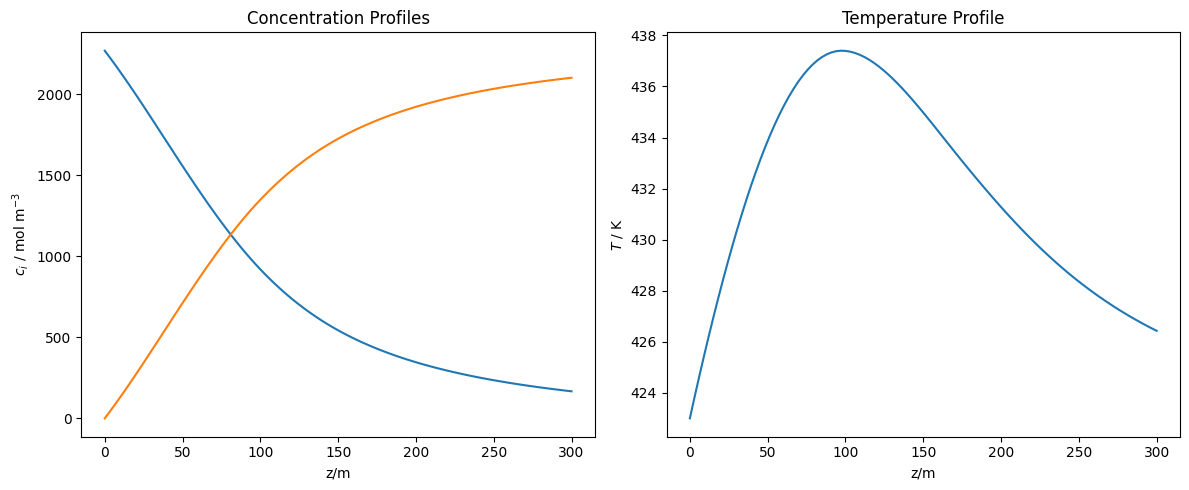

In [6]:
#import packages
import numpy as np
import scipy.integrate as integ #important for initial value problem
import matplotlib.pyplot as plt #figures

# define variables

E_A = 72500 #activation energy / J/mol
u = 1 # fluid velocity / m/s
Delta_R_H = -92.2 *10**3 #reaction enthalpy / J/mol
rho = 1000 #density / kg/m^3
c_p = 4.19*10**3 #heat capacity / J/kg*K
d_R = 0.03 #tube diameter / m
h_wall = 0.5*10**3 #wall heat transfer coefficient / W/m^2*K
T_wall = 423 #wall temperature / K
L = 300 #reactor length / m
k_0 = 5.01*10**6 #pre-exponential factor / 1/s
R = 8.314 #gas constant / J/mol*K

# boundary conditions
c_EO_in = 2.27*10**3 #inlet concentration of EO / mol/m^3
T_in = 423 #inlet temperature / K

def kinetics(c_EO, T):
    'assume first order kinetics in c_EO'
    k = k_0 * np.exp(-E_A/(R*T)) #rate constant / 1/s
    r = k * c_EO #reaction rate / mol/m^3/s
    return r

def PFTR(z, f):
    'Function for component balance and energy balance'
    # f is a vector containing concentrations of components c_EO (f[0]) and c_EG (f[1]) and temperature T of the reaction mixture (f[2])
    c_EO = f[0]
    c_EG = f[1]
    T = f[2]
    
    # reaction rate from kinetics function
    r = kinetics(c_EO, T)
    
    # differential equations
    dc_EO_dz = -r/u #change in EO concentration along the reactor length / mol/m^3/m
    dc_EG_dz = r/u #change in EG concentration along the reactor length / mol/m^3/m
    dT_dz = (-Delta_R_H * r - (4*h_wall/d_R)*(T - T_wall))/(rho*c_p*u) #change in temperature along the reactor length / K/m
    
    dfdz = np.empty_like(f)
    dfdz[0] = dc_EO_dz
    dfdz[1] = dc_EG_dz
    dfdz[2] = dT_dz
    return dfdz

# vector of initial conditions
f_init = np.array([c_EO_in, 0, T_in]) #initial concentrations and temperature

# solve the system of ODEs using scipy's solve_ivp
tspan = (0, L) #span of the reactor length
teval = np.linspace(0, L, 100) #points at which to evaluate the solution
sol = integ.solve_ivp(PFTR, tspan, f_init, t_eval=teval)

# postprocessing and plotting

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.set(xlabel='z/m', ylabel='$c_i$ / mol m$^{-3}$', title='Concentration Profiles')
ax1.plot(sol.t, sol.y[0], label='$c_{EO}$')
ax1.plot(sol.t, sol.y[1], label='$c_{EG}$')

ax2.set(xlabel='z/m', ylabel='$T$ / K', title='Temperature Profile')
ax2.plot(sol.t, sol.y[2], label='$T$')
fig.tight_layout()

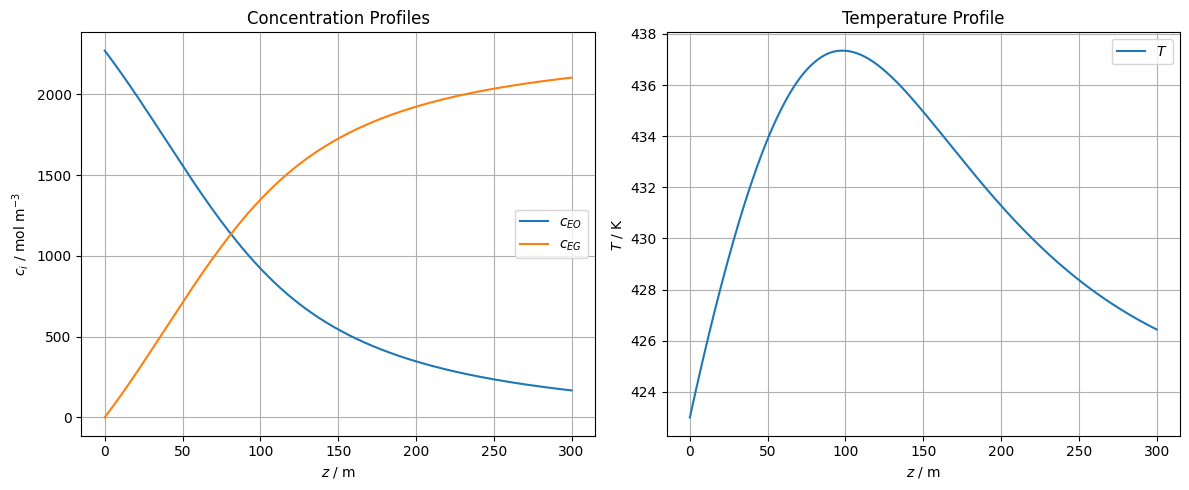

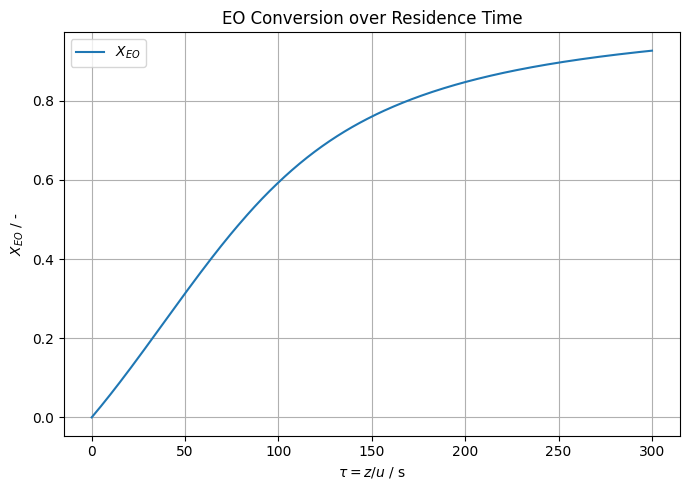

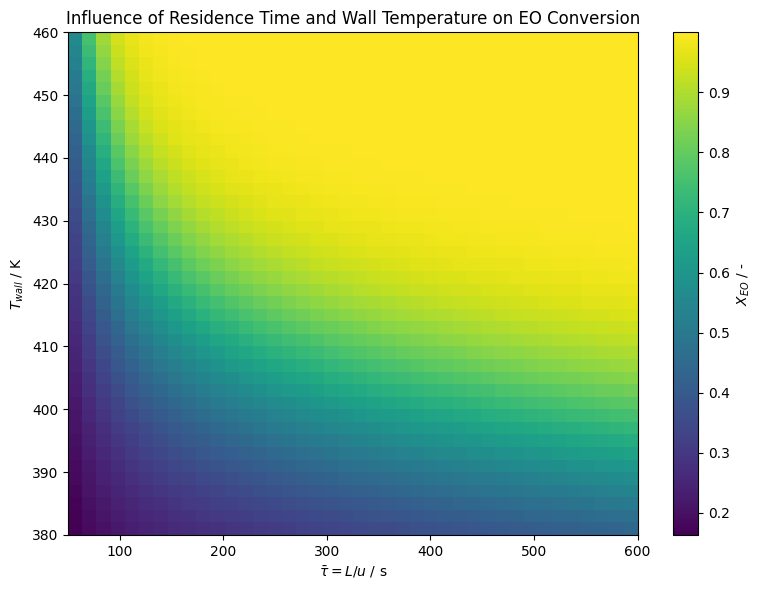

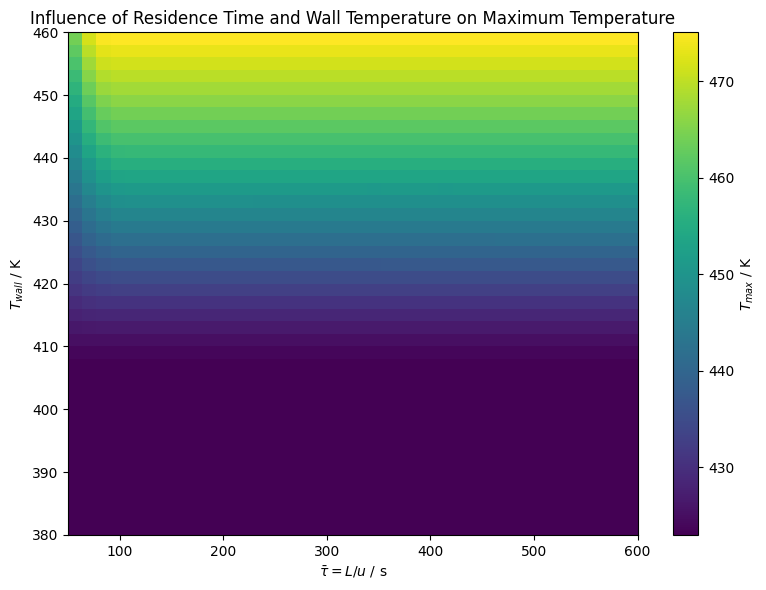

In [7]:
#import packages
import numpy as np
import scipy.integrate as integ
import matplotlib.pyplot as plt

# define variables
E_A = 72500                 # activation energy / J/mol
u = 1                       # fluid velocity / m/s
Delta_R_H = -92.2e3         # reaction enthalpy / J/mol
rho = 1000                  # density / kg/m^3
c_p = 4.19e3                # heat capacity / J/(kg K)
d_R = 0.03                  # tube diameter / m
h_wall = 0.5e3              # wall heat transfer coefficient / W/(m^2 K)
T_wall = 423                # wall temperature / K
L = 300                     # reactor length / m
k_0 = 5.01e6                # pre-exponential factor / 1/s
R = 8.314                   # gas constant / J/(mol K)

# boundary conditions
c_EO_in = 2.27e3            # inlet concentration EO / mol/m^3
T_in = 423                  # inlet temperature / K


def kinetics(c_EO, T):
    """First order kinetics in EO"""
    k = k_0 * np.exp(-E_A / (R * T))
    r = k * c_EO
    return r


def PFTR(z, f, u, T_wall, d_R, h_wall):
    """Component and energy balances for PFTR"""
    c_EO = f[0]
    c_EG = f[1]
    T = f[2]

    r = kinetics(c_EO, T)

    dc_EO_dz = -r / u
    dc_EG_dz = r / u

    dT_dz = (
        -Delta_R_H * r
        - (4 * h_wall / d_R) * (T - T_wall)
    ) / (rho * c_p * u)

    return np.array([dc_EO_dz, dc_EG_dz, dT_dz])


def run_simulation(L=300, u=1, T_wall=423, d_R=0.03, h_wall=500, T_in=423):
    """Solves the PFTR model for given parameters"""
    f_init = np.array([c_EO_in, 0, T_in])

    zspan = (0, L)
    zeval = np.linspace(0, L, 300)

    sol = integ.solve_ivp(
        lambda z, f: PFTR(z, f, u, T_wall, d_R, h_wall),
        zspan,
        f_init,
        t_eval=zeval,
        method='BDF'
    )

    return sol


# ============================================================
# 1. Basisfall
# ============================================================

sol = run_simulation(L=L, u=u, T_wall=T_wall, d_R=d_R, h_wall=h_wall, T_in=T_in)

X_EO = (c_EO_in - sol.y[0]) / c_EO_in
tau = sol.t / u

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(sol.t, sol.y[0], label=r'$c_{EO}$')
ax1.plot(sol.t, sol.y[1], label=r'$c_{EG}$')
ax1.set_xlabel(r'$z$ / m')
ax1.set_ylabel(r'$c_i$ / mol m$^{-3}$')
ax1.set_title('Concentration Profiles')
ax1.legend()
ax1.grid(True)

ax2.plot(sol.t, sol.y[2], label=r'$T$')
ax2.set_xlabel(r'$z$ / m')
ax2.set_ylabel(r'$T$ / K')
ax2.set_title('Temperature Profile')
ax2.legend()
ax2.grid(True)

fig.tight_layout()
plt.show()


# ============================================================
# 2. Umsatz als Funktion der Verweilzeit
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(tau, X_EO, label=r'$X_{EO}$')
plt.xlabel(r'$\tau = z/u$ / s')
plt.ylabel(r'$X_{EO}$ / -')
plt.title('EO Conversion over Residence Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 3. Parameterstudie: tau und T_wall
# ============================================================

tau_values = np.linspace(50, 600, 40)        # residence time / s
Twall_values = np.linspace(380, 460, 40)     # wall temperature / K

X_out = np.zeros((len(Twall_values), len(tau_values)))
T_max = np.zeros((len(Twall_values), len(tau_values)))

for i, Twall_i in enumerate(Twall_values):
    for j, tau_i in enumerate(tau_values):

        u_i = L / tau_i

        sol_i = run_simulation(
            L=L,
            u=u_i,
            T_wall=Twall_i,
            d_R=d_R,
            h_wall=h_wall,
            T_in=T_in
        )

        c_EO_out = sol_i.y[0, -1]
        X_out[i, j] = (c_EO_in - c_EO_out) / c_EO_in
        T_max[i, j] = np.max(sol_i.y[2])


# ============================================================
# 4. Heatmap: EO-Umsatz
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(
    X_out,
    origin='lower',
    aspect='auto',
    extent=[
        tau_values.min(),
        tau_values.max(),
        Twall_values.min(),
        Twall_values.max()
    ]
)

plt.colorbar(label=r'$X_{EO}$ / -')
plt.xlabel(r'$\bar{\tau} = L/u$ / s')
plt.ylabel(r'$T_{wall}$ / K')
plt.title('Influence of Residence Time and Wall Temperature on EO Conversion')
plt.tight_layout()
plt.show()


# ============================================================
# 5. Heatmap: Maximale Temperatur
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(
    T_max,
    origin='lower',
    aspect='auto',
    extent=[
        tau_values.min(),
        tau_values.max(),
        Twall_values.min(),
        Twall_values.max()
    ]
)

plt.colorbar(label=r'$T_{max}$ / K')
plt.xlabel(r'$\bar{\tau} = L/u$ / s')
plt.ylabel(r'$T_{wall}$ / K')
plt.title('Influence of Residence Time and Wall Temperature on Maximum Temperature')
plt.tight_layout()
plt.show()